## Seminário I - Cálculo Numérico | Interpolação Polinomial e Mínimos Quadrados

---

## 1. Introdução

O nosso principal problema numérico hoje é responder à seguinte pergunta: **como obter o valor de uma função para um $x$ que não foi medido durante um experimento?** A resposta depende muito da qualidade dos nossos dados e do nosso objetivo.


## Bibliotecas Utilizadas


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# configuração visual baseada no estilo do repositório
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#ccc',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'text.color':       '#eee',
    'grid.color':       '#2a2d3a',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'font.family':      'monospace',
})

## 2. Interpolação Polinomial

Quando queremos estimar o valor de $f(x)$ para um ponto intermediário que está estritamente entre duas medidas conhecidas, nós utilizamos as técnicas de interpolação. A ideia é encontrar um polinômio que passe _exatamente_ por todos os pontos que temos.

### Forma de Lagrange

A Forma de Lagrange constrói o polinômio interpolador diretamente a partir dos pontos originais.

- A fórmula genérica é dada pelo somatório:  
  **$P_n(x) = \sum_{i=0}^{n} L_i(x) \cdot f(x_i)$**

- Onde cada polinômio base $L_i(x)$ é construído para isolar o impacto de cada ponto:  
  **$L_i(x) = \frac{(x-x_0)(x-x_1)\dots(x-x_{i-1})(x-x_{i+1})\dots(x-x_n)}{(x_i-x_0)(x_i-x_1)\dots(x_i-x_{i-1})(x_i-x_{i+1})\dots(x_i-x_n)}$**


In [2]:
def interpolacao_lagrange(x, y, x_interp):
    """
    Realiza a interpolação polinomial utilizando o método de Lagrange.
    """
    n = len(x)
    is_scalar = np.isscalar(x_interp)
    if is_scalar:
        x_interp = np.array([x_interp])
        
    y_interp = np.zeros_like(x_interp, dtype=float)
    
    for i in range(n):
        L_i = np.ones_like(x_interp, dtype=float)
        for j in range(n):
            if i != j:
                L_i *= (x_interp - x[j]) / (x[i] - x[j])
        y_interp += y[i] * L_i
        
    return y_interp[0] if is_scalar else y_interp

### Forma de Newton

Para resolver a ineficiência computacional de recalcular todos os termos quando um novo ponto é adicionado, Newton utiliza o **Operador Diferenças Divididas**.

- A diferença dividida é dada por: **$f[x_0, x_1] = \frac{f(x_1) - f(x_0)}{x_1 - x_0}$**
- O polinômio é construído de forma incremental:  
  **$P_n(x) = a_0 + a_1(x-x_0) + a_2(x-x_0)(x-x_1) + \dots + a_n(x-x_0)\dots(x-x_{n-1})$**
- Os coeficientes $a_n$ correspondem aos resultados dos respectivos operadores de diferenças divididas ($a_0 = f[x_0]$, $a_1 = f[x_0, x_1]$, etc).


In [3]:
def diferencas_divididas(x, y):
    # Calcula a tabela de diferenças divididas de Newton
    n = len(y)
    tabela = np.zeros((n, n))
    tabela[:, 0] = y
    
    for j in range(1, n):
        for i in range(n - j):
            tabela[i][j] = (tabela[i + 1][j - 1] - tabela[i][j - 1]) / (x[i + j] - x[i])
            
    return tabela[0, :] # Retorna apenas a primeira linha (os coeficientes a_n)

def interpolacao_newton(x, y, x_interp):
    # Realiza a interpolação polinomial utilizando o método de Newton
    coeficientes = diferencas_divididas(x, y)
    n = len(x)
    
    is_scalar = np.isscalar(x_interp)
    if is_scalar:
        x_interp = np.array([x_interp])
        
    y_interp = np.zeros_like(x_interp, dtype=float)
    
    for k in range(len(x_interp)):
        p = coeficientes[0]
        fator = 1.0
        for i in range(1, n):
            fator *= (x_interp[k] - x[i - 1])
            p += coeficientes[i] * fator
        y_interp[k] = p
        
    return y_interp[0] if is_scalar else y_interp

## 3. Ajuste de Curvas: Método dos Mínimos Quadrados (MMQ)

Quando os dados vêm de experimentos e contêm **erros de medição**, a interpolação polinomial falha, gerando curvas que oscilam fortemente. Para estes casos, usamos o Ajuste de Curvas.

Definimos o desvio de um ponto $P$ em relação à curva como $d_i = y_i - f(x_i)$. O Método dos Mínimos Quadrados busca encontrar uma curva que minimize o **Desvio Total** $D = \sum_{i=1}^{n} d_i^2$.

### Caso 1: A Reta ($y = ax + b$)

Para a reta, os coeficientes que minimizam o erro são dados resolvendo o sistema normal, chegando às fórmulas:
**$a = \frac{n\sum x_i y_i - \sum x_i \sum y_i}{n\sum x_i^2 - (\sum x_i)^2}$** e **$b = \frac{\sum y_i - a\sum x_i}{n}$**

### Caso 2: Curva Exponencial (Redução ao Caso Linear)

Se os pontos sugerem o formato $y = be^{ax}$, não precisamos inventar nova matemática. Aplicamos o logaritmo natural de ambos os lados:
$\ln y = \ln(b e^{ax}) \Rightarrow \ln y = \ln b + ax$

Fazendo as mudanças de variáveis **$Y = \ln y$** e **$B = \ln b$**, obtemos a reta **$Y = ax + B$**. Após encontrar $B$, basta fazer $b = e^B$.


In [4]:
def minimos_quadrados_reta(x, y):
    """
    Ajusta uma reta y = ax + b aos pontos (x, y) usando Mínimos Quadrados.
    """
    n = len(x)
    soma_x = np.sum(x)
    soma_y = np.sum(y)
    soma_x2 = np.sum(x**2)
    soma_xy = np.sum(x * y)
    
    A = np.array([[n, soma_x], [soma_x, soma_x2]])
    B = np.array([soma_y, soma_xy])
    
    coefs = np.linalg.solve(A, B)
    b, a = coefs[0], coefs[1]
    
    return a, b

def minimos_quadrados_exponencial(x, y):
    """
    Ajusta a curva y = b * e^(ax) fazendo a linearização Y = ln(y).
    """
    # Redução ao caso linear: Y = ln(y)
    Y = np.log(y)
    
    # Usa a função da reta para achar 'a' e 'B'
    a, B = minimos_quadrados_reta(x, Y)
    
    # Recupera o 'b' original
    b = np.exp(B)
    
    return a, b

## 4. Estudo de Caso Numérico

Vamos testar nossos algoritmos com exemplos numéricos diferentes e comparar o comportamento de interpolação e ajustes de curva.


In [5]:
# Exemplo de interpolação
x_ex1 = np.array([0.0, 2.0, 3.5])
y_ex1 = np.array([1.0, 2.8, 3.7])
print("--- Exemplo Interpolação ---")
print(f"P(1.5) interpolado via Lagrange: {interpolacao_lagrange(x_ex1, y_ex1, 1.5):.4f}")
print(f"P(1.5) interpolado via Newton:   {interpolacao_newton(x_ex1, y_ex1, 1.5):.4f}")
print("Polinômio resultante aproximado com os dados acima.\n")

# Exemplo de MMQ reta
x_ex2 = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
y_ex2 = np.array([1.1, 2.0, 2.9, 4.2, 5.1])
a_reta, b_reta = minimos_quadrados_reta(x_ex2, y_ex2)
print("--- Exemplo MMQ Reta ---")
print(f"Equação encontrada: y = {a_reta:.2f}x + {b_reta:.2f}")
print("Este ajuste mostra a tendência linear dos dados.\n")

# Exemplo de MMQ exponencial
x_ex3 = np.array([0.0, 0.5, 1.0, 1.5, 2.0])
y_ex3 = np.array([1.0, 1.8, 3.2, 5.6, 8.7])
a_exp, b_exp = minimos_quadrados_exponencial(x_ex3, y_ex3)
print("--- Exemplo MMQ Exponencial ---")
print(f"Equação encontrada: y = {b_exp:.4f} * e^({a_exp:.4f}x)")
print("Este ajuste mostra como dados de crescimento exponencial podem ser tratados.\n")

--- Exemplo Interpolação ---
P(1.5) interpolado via Lagrange: 2.4143
P(1.5) interpolado via Newton:   2.4143
Polinômio resultante aproximado com os dados acima.

--- Exemplo MMQ Reta ---
Equação encontrada: y = 1.02x + 1.02
Este ajuste mostra a tendência linear dos dados.

--- Exemplo MMQ Exponencial ---
Equação encontrada: y = 1.0357 * e^(1.0923x)
Este ajuste mostra como dados de crescimento exponencial podem ser tratados.



## 5. Prática Final: O Fenômeno Visual

Vamos testar a diferença visual entre forçar um polinômio interpolador e encontrar o Ajuste de Mínimos Quadrados em um conjunto de pontos com **ruído experimental**.


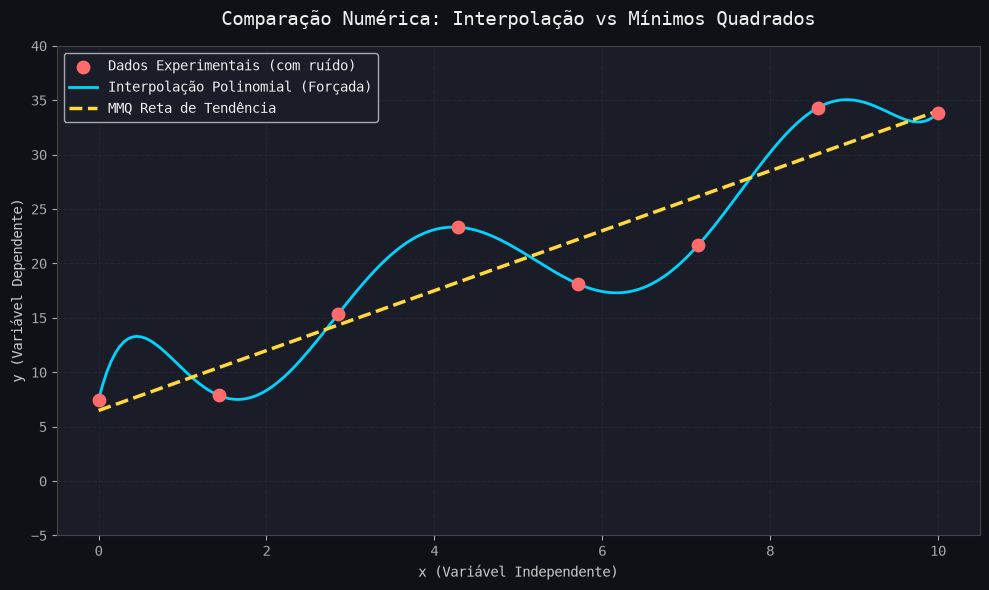

In [6]:
# Gerando dados experimentais ruidosos
np.random.seed(42)
x_dados = np.linspace(0, 10, 8)
y_real = 2.5 * x_dados + 5.0
y_ruidoso = y_real + np.random.normal(0, 5, len(x_dados))

# Dominio contínuo para as curvas
x_plot = np.linspace(0, 10, 200)

y_interp = interpolacao_lagrange(x_dados, y_ruidoso, x_plot)
a_mmq, b_mmq = minimos_quadrados_reta(x_dados, y_ruidoso)
y_mmq = a_mmq * x_plot + b_mmq

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x_dados, y_ruidoso, color='#ff6b6b', s=80, zorder=5, label='Dados Experimentais (com ruído)')
ax.plot(x_plot, y_interp, color='#00d4ff', lw=2, label='Interpolação Polinomial (Forçada)')
ax.plot(x_plot, y_mmq, color='#ffd93d', lw=2.5, ls='--', label=f'MMQ Reta de Tendência')

ax.set_ylim([-5, 40]) # limitando para focar no desvio
ax.set_title('Comparação Numérica: Interpolação vs Mínimos Quadrados', fontsize=14, pad=15)
ax.set_xlabel('x (Variável Independente)')
ax.set_ylabel('y (Variável Dependente)')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True)
plt.tight_layout()
plt.show()

## 6. Caso Real: Mapeamento de Poluição do Ar com Interpolação Bicúbica

### O Problema

Imagine que precisamos mapear o **Índice de Qualidade do Ar (IQAr)** de uma cidade inteira. O grande obstáculo é que não temos dados de cada metro quadrado, seria inviável instalar sensores por toda a área. Possuímos apenas **estações de monitoramento espalhadas pelo mapa**.

Se tentássemos usar uma única variável, como fizemos até agora ($y = f(x)$), o modelo seria **inútil**: a poluição depende tanto da **latitude** quanto da **longitude** da localização. Precisamos de uma função $z = f(x, y)$, ou seja, uma **interpolação bivariada** (em duas dimensões).

### A Solução: Interpolação Bicúbica

A interpolação bicúbica é o padrão-ouro para reconstruir superfícies suaves a partir de dados em grade. Para prever a poluição em um bairro sem sensor, o algoritmo faz o seguinte processo:

---

#### Passo 1

O algoritmo "puxa" os dados das **16 estações** mais próximas ao redor do ponto alvo, formando um raio de observação amplo em um formato **4×4**.

#### Passo 2

Para cada uma das 4 linhas da grade, traça uma **curva cúbica** calculando como a poluição está aumentando ou diminuindo na **direção Leste-Oeste**. Cada curva cúbica é construída pelo polinômio interpolador de grau 3, que passa exatamente pelos 4 pontos da linha.

#### Passo 3

O Passo 2 produziu 4 valores intermediários (um por linha). Agora, o algoritmo pega essas tendências e faz um **cruzamento matemático** na **direção Norte-Sul**: outra interpolação cúbica, desta vez usando os 4 resultados parciais como novos pontos.

#### Passo 4

A união dessas duas direções entrega o **índice de poluição estimado** com altíssima precisão para o bairro vazio. Matematicamente:

$$z = f(x, y) = \sum_{j=0}^{3} b_j(y) \cdot \left[ \sum_{i=0}^{3} a_{ij}(x) \cdot z_{ij} \right]$$

Onde $a_{ij}(x)$ são os coeficientes de Lagrange na direção $x$ e $b_j(y)$ os coeficientes na direção $y$.


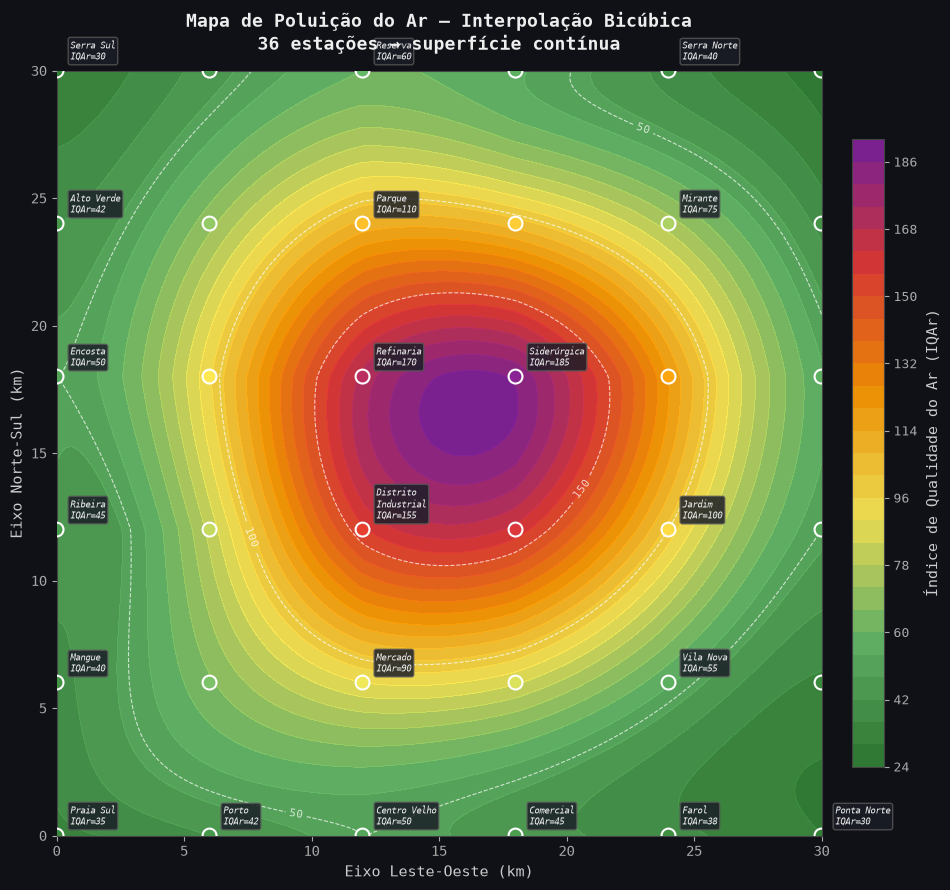

In [7]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle

# Grade de estações de monitoramento 6×6 (cidade ~30 km × 30 km)
# Cada valor é o Índice de Qualidade do Ar (IQAr, escala 0–200)

# Coordenadas das estações (espaçamento regular de 6 km)
x_estacoes = np.array([0, 6, 12, 18, 24, 30], dtype=float)  # km (Leste-Oeste)
y_estacoes = np.array([0, 6, 12, 18, 24, 30], dtype=float)  # km (Norte-Sul)

# IQAr medido em cada estação (grade 6×6 = 36 sensores no total)
# Simula zona industrial pesada no centro-norte e ar limpo nas bordas
IQAr_grade = np.array([
    [ 35,  42,  50,  45,  38,  30],   # y=0  (litoral sul, ar limpo)
    [ 40,  65,  90,  85,  55,  35],   # y=6
    [ 45,  80, 155, 160, 100,  50],   # y=12 (zona industrial)
    [ 50,  95, 170, 185, 120,  55],   # y=18 (pico de poluição)
    [ 42,  70, 110, 105,  75,  40],   # y=24
    [ 30,  45,  60,  55,  40,  28],   # y=30 (serra, ar puro)
], dtype=float)

nomes_bairros = {
    (0,0): 'Praia Sul',    (6,0): 'Porto',       (12,0): 'Centro Velho',
    (18,0): 'Comercial',   (24,0): 'Farol',      (30,0): 'Ponta Norte',
    (0,6): 'Mangue',       (12,6): 'Mercado',    (24,6): 'Vila Nova',
    (0,12): 'Ribeira',     (12,12): 'Distrito\nIndustrial', (24,12): 'Jardim',
    (0,18): 'Encosta',     (12,18): 'Refinaria', (18,18): 'Siderúrgica',
    (0,24): 'Alto Verde',  (12,24): 'Parque',    (24,24): 'Mirante',
    (0,30): 'Serra Sul',   (12,30): 'Reserva',   (24,30): 'Serra Norte',
}


# Interpolação Cúbica 1D (Lagrange grau 3, usando 4 pontos)

def cubica_lagrange(x_pts, z_pts, x_alvo):
    """
    Interpola o valor em x_alvo usando exatamente 4 pontos (polinômio grau 3).
    Esta é a mesma forma de Lagrange da seção 2, aplicada a 4 pontos.
    """
    assert len(x_pts) == 4 and len(z_pts) == 4
    resultado = 0.0
    for i in range(4):
        L_i = 1.0
        for j in range(4):
            if i != j:
                L_i *= (x_alvo - x_pts[j]) / (x_pts[i] - x_pts[j])
        resultado += z_pts[i] * L_i
    return resultado

# 
# Interpolação Bicúbica (os 4 passos explicados acima)

def interpolacao_bicubica(x_grade, y_grade, Z_grade, x_alvo, y_alvo):
    """
    Interpolação bicúbica em uma grade regular.
    
    Processo:
      1. Encontra a sub-grade 4×4 ao redor do ponto alvo
      2. Interpola cubicamente nas 4 linhas (direção X → Leste-Oeste)
      3. Interpola cubicamente nos 4 resultados (direção Y → Norte-Sul)
      4. Retorna o valor final (colapso)
    """
    nx, ny = len(x_grade), len(y_grade)
    
    # --- PASSO 1: Seleção da sub-grade 4×4 ---
    # Encontra o índice da célula que contém x_alvo
    ix = np.searchsorted(x_grade, x_alvo) - 1
    iy = np.searchsorted(y_grade, y_alvo) - 1
    
    # Centraliza a janela 4×4 (índices i-1 a i+2)
    ix = np.clip(ix, 1, nx - 3)
    iy = np.clip(iy, 1, ny - 3)
    
    # Extrai as coordenadas e valores da sub-grade 4×4
    x4 = x_grade[ix-1 : ix+3]   # 4 pontos em x
    y4 = y_grade[iy-1 : iy+3]   # 4 pontos em y
    Z4 = Z_grade[iy-1 : iy+3, ix-1 : ix+3]  # sub-matriz 4×4
    
    # --- PASSO 2: Varredura Leste-Oeste (eixo X) ---
    # Para cada uma das 4 linhas, interpola na direção x
    z_parciais = np.zeros(4)
    for j in range(4):
        z_parciais[j] = cubica_lagrange(x4, Z4[j, :], x_alvo)
    
    # --- PASSO 3 + 4: Cruzamento Norte-Sul (eixo Y) e Colapso ---
    z_final = cubica_lagrange(y4, z_parciais, y_alvo)
    
    return z_final


# Gerar superfície interpolada sobre toda a cidade

resolucao = 250
x_fino = np.linspace(x_estacoes[0], x_estacoes[-1], resolucao)
y_fino = np.linspace(y_estacoes[0], y_estacoes[-1], resolucao)
X_fino, Y_fino = np.meshgrid(x_fino, y_fino)

Z_bicubica = np.zeros_like(X_fino)
for i in range(resolucao):
    for j in range(resolucao):
        Z_bicubica[i, j] = interpolacao_bicubica(
            x_estacoes, y_estacoes, IQAr_grade, X_fino[0, j], Y_fino[i, 0]
        )


# Paleta de cores: ar limpo (verde) → moderado (amarelo) → ruim (vermelho)

cores_ar = ['#2e7d32', '#66bb6a', '#ffee58', '#ff9800', '#e53935', '#7b1fa2']
cmap_ar = LinearSegmentedColormap.from_list('poluicao', cores_ar, N=256)

# Mapa de poluição do ar
fig, ax = plt.subplots(figsize=(11, 9))

im = ax.contourf(X_fino, Y_fino, Z_bicubica, levels=30, cmap=cmap_ar, alpha=0.92)
contornos = ax.contour(X_fino, Y_fino, Z_bicubica, levels=[50, 100, 150],
                       colors='white', linewidths=0.8, linestyles='--', alpha=0.7)
ax.clabel(contornos, fmt='%d', fontsize=8, colors='white')

# Estações como pontos no mapa
Xg, Yg = np.meshgrid(x_estacoes, y_estacoes)
scatter = ax.scatter(Xg.ravel(), Yg.ravel(), c=IQAr_grade.ravel(), cmap=cmap_ar,
                     s=100, edgecolors='white', linewidths=1.5, zorder=5,
                     vmin=Z_bicubica.min(), vmax=Z_bicubica.max())

# Rótulos selecionados
for (bx, by), nome in nomes_bairros.items():
    iy_idx = np.where(y_estacoes == by)[0][0]
    ix_idx = np.where(x_estacoes == bx)[0][0]
    valor = IQAr_grade[iy_idx, ix_idx]
    ax.annotate(f'{nome}\nIQAr={valor:.0f}',
                (bx, by), textcoords='offset points', xytext=(10, 8),
                fontsize=6.5, color='#eee', fontstyle='italic',
                bbox=dict(boxstyle='round,pad=0.25', fc='#1a1d27', ec='#555', alpha=0.85))

cbar = fig.colorbar(im, ax=ax, shrink=0.82, pad=0.03)
cbar.set_label('Índice de Qualidade do Ar (IQAr)', fontsize=11)
cbar.ax.tick_params(labelsize=9)

ax.set_xlabel('Eixo Leste-Oeste (km)', fontsize=11)
ax.set_ylabel('Eixo Norte-Sul (km)', fontsize=11)
ax.set_title('Mapa de Poluição do Ar — Interpolação Bicúbica\n36 estações → superfície contínua',
             fontsize=13, pad=15, fontweight='bold')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

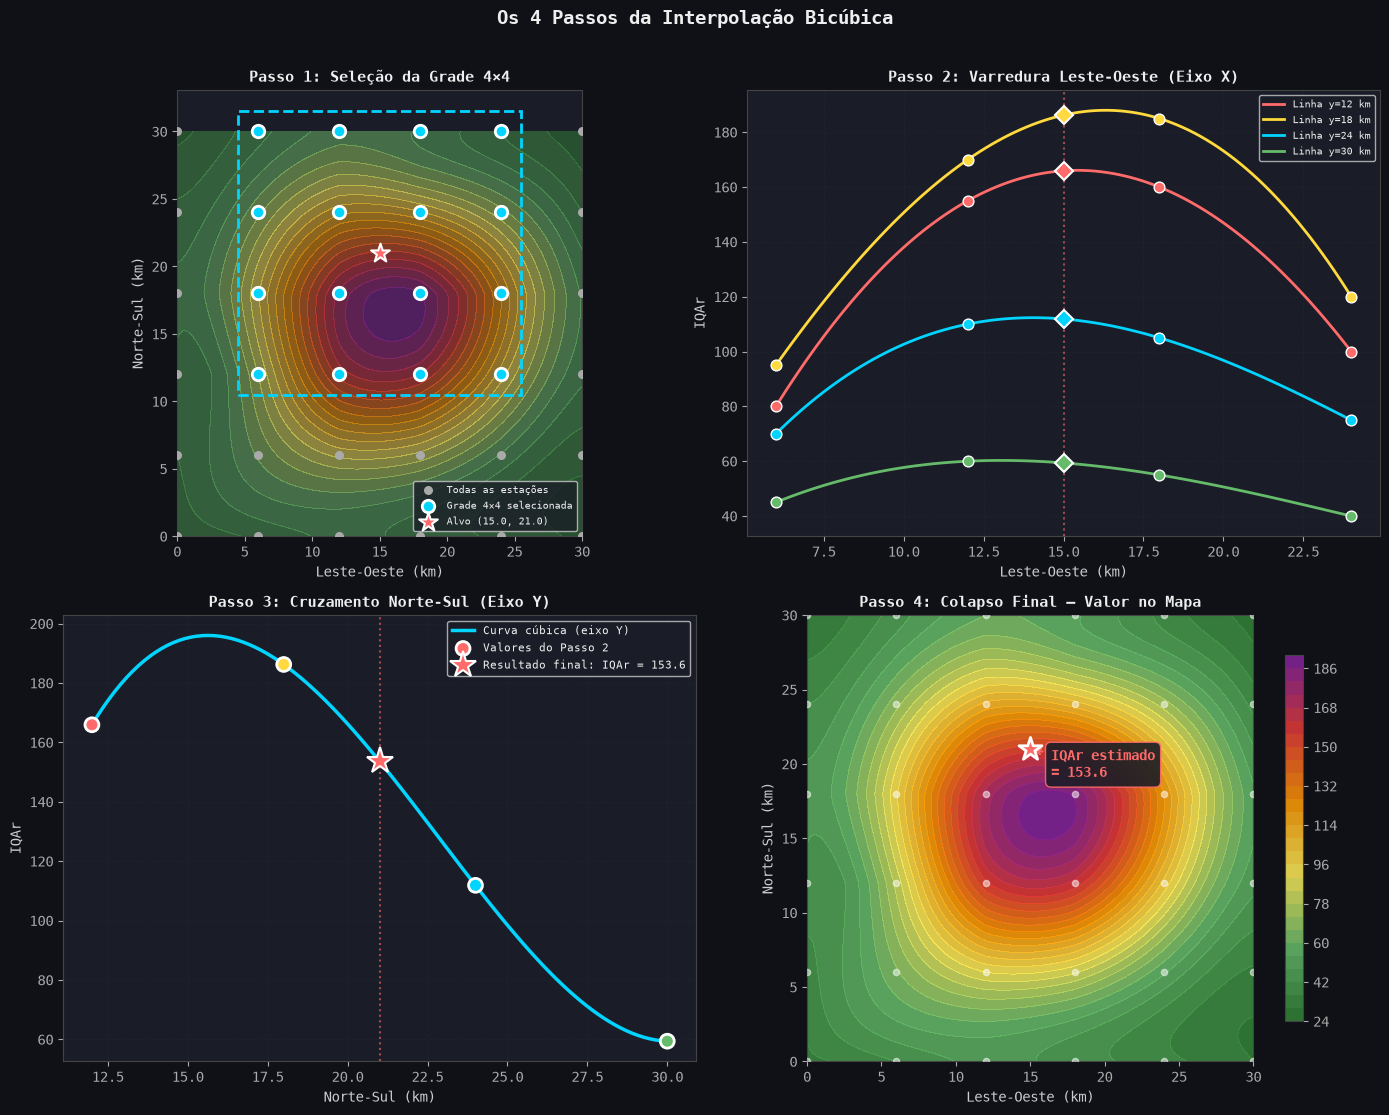


>>> Resultado: o bairro em (15.0, 21.0) km tem IQAr estimado = 153.61
    (Interpolado a partir de uma sub-grade 4×4 com 16 estações vizinhas)


In [8]:
# Visualização dos 4 passos

# Ponto alvo: bairro sem sensor em (15, 21) — entre as estações
x_alvo, y_alvo = 15.0, 21.0

# PASSO 1: encontrar a sub-grade 4×4
ix = np.clip(np.searchsorted(x_estacoes, x_alvo) - 1, 1, 4)
iy = np.clip(np.searchsorted(y_estacoes, y_alvo) - 1, 1, 4)
x4 = x_estacoes[ix-1 : ix+3]
y4 = y_estacoes[iy-1 : iy+3]
Z4 = IQAr_grade[iy-1 : iy+3, ix-1 : ix+3]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Seleção da grade 4x4
ax = axes[0, 0]
im0 = ax.contourf(X_fino, Y_fino, Z_bicubica, levels=20, cmap=cmap_ar, alpha=0.5)
ax.scatter(Xg.ravel(), Yg.ravel(), c='#aaa', s=30, zorder=3, label='Todas as estações')

# Destacar a sub-grade 4×4 selecionada
X4g, Y4g = np.meshgrid(x4, y4)
ax.scatter(X4g.ravel(), Y4g.ravel(), c='#00d4ff', s=80, edgecolors='white',
           linewidths=2, zorder=5, label='Grade 4×4 selecionada')
rect = Rectangle((x4[0]-1.5, y4[0]-1.5), x4[-1]-x4[0]+3, y4[-1]-y4[0]+3,
                  linewidth=2, edgecolor='#00d4ff', facecolor='none', linestyle='--', zorder=4)
ax.add_patch(rect)

# Ponto alvo
ax.scatter(x_alvo, y_alvo, c='#ff6b6b', s=200, marker='*', edgecolors='white',
           linewidths=1.5, zorder=6, label=f'Alvo ({x_alvo}, {y_alvo})')
ax.set_title('Passo 1: Seleção da Grade 4×4', fontsize=11, fontweight='bold')
ax.legend(fontsize=7.5, loc='lower right')
ax.set_xlabel('Leste-Oeste (km)')
ax.set_ylabel('Norte-Sul (km)')
ax.set_aspect('equal')

# Varredura Leste-Oeste
ax = axes[0, 1]
x_curva = np.linspace(x4[0], x4[-1], 100)
cores_linhas = ['#ff6b6b', '#ffd93d', '#00d4ff', '#66bb6a']

z_parciais = np.zeros(4)
for j in range(4):
    z_curva = np.array([cubica_lagrange(x4, Z4[j, :], xv) for xv in x_curva])
    z_parciais[j] = cubica_lagrange(x4, Z4[j, :], x_alvo)
    ax.plot(x_curva, z_curva, color=cores_linhas[j], lw=2,
            label=f'Linha y={y4[j]:.0f} km')
    ax.scatter(x4, Z4[j, :], color=cores_linhas[j], s=60, edgecolors='white',
               linewidths=1, zorder=5)
    # Marca o valor intermediário
    ax.plot(x_alvo, z_parciais[j], 'D', color=cores_linhas[j], markersize=9,
            markeredgecolor='white', markeredgewidth=1.5, zorder=6)

ax.axvline(x_alvo, color='#ff6b6b', ls=':', alpha=0.6, lw=1.5)
ax.set_title('Passo 2: Varredura Leste-Oeste (Eixo X)', fontsize=11, fontweight='bold')
ax.set_xlabel('Leste-Oeste (km)')
ax.set_ylabel('IQAr')
ax.legend(fontsize=7.5)
ax.grid(True, alpha=0.3)

# Cruzamento Norte-Sul
ax = axes[1, 0]
y_curva = np.linspace(y4[0], y4[-1], 100)
z_cruzamento = np.array([cubica_lagrange(y4, z_parciais, yv) for yv in y_curva])
z_final = cubica_lagrange(y4, z_parciais, y_alvo)

ax.plot(y_curva, z_cruzamento, color='#00d4ff', lw=2.5, label='Curva cúbica (eixo Y)')
ax.scatter(y4, z_parciais, c=cores_linhas, s=100, edgecolors='white',
           linewidths=2, zorder=5, label='Valores do Passo 2')
ax.plot(y_alvo, z_final, '*', color='#ff6b6b', markersize=20,
        markeredgecolor='white', markeredgewidth=1.5, zorder=6,
        label=f'Resultado final: IQAr = {z_final:.1f}')
ax.axvline(y_alvo, color='#ff6b6b', ls=':', alpha=0.6, lw=1.5)

ax.set_title('Passo 3: Cruzamento Norte-Sul (Eixo Y)', fontsize=11, fontweight='bold')
ax.set_xlabel('Norte-Sul (km)')
ax.set_ylabel('IQAr')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Resultado no Mapa
ax = axes[1, 1]
im3 = ax.contourf(X_fino, Y_fino, Z_bicubica, levels=30, cmap=cmap_ar, alpha=0.85)
ax.scatter(Xg.ravel(), Yg.ravel(), c='white', s=20, alpha=0.5, zorder=3)

# Marca o ponto alvo com o resultado
ax.scatter(x_alvo, y_alvo, c='#ff6b6b', s=300, marker='*', edgecolors='white',
           linewidths=2, zorder=6)
ax.annotate(f'IQAr estimado\n= {z_final:.1f}',
            (x_alvo, y_alvo), textcoords='offset points', xytext=(15, -20),
            fontsize=10, color='#ff6b6b', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', fc='#1a1d27', ec='#ff6b6b', alpha=0.9),
            arrowprops=dict(arrowstyle='->', color='#ff6b6b', lw=1.5))

fig.colorbar(im3, ax=ax, shrink=0.82)
ax.set_title('Passo 4: Colapso Final — Valor no Mapa', fontsize=11, fontweight='bold')
ax.set_xlabel('Leste-Oeste (km)')
ax.set_ylabel('Norte-Sul (km)')
ax.set_aspect('equal')

fig.suptitle('Os 4 Passos da Interpolação Bicúbica',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'\n>>> Resultado: o bairro em ({x_alvo}, {y_alvo}) km tem IQAr estimado = {z_final:.2f}')
print(f'    (Interpolado a partir de uma sub-grade 4×4 com {4*4} estações vizinhas)')

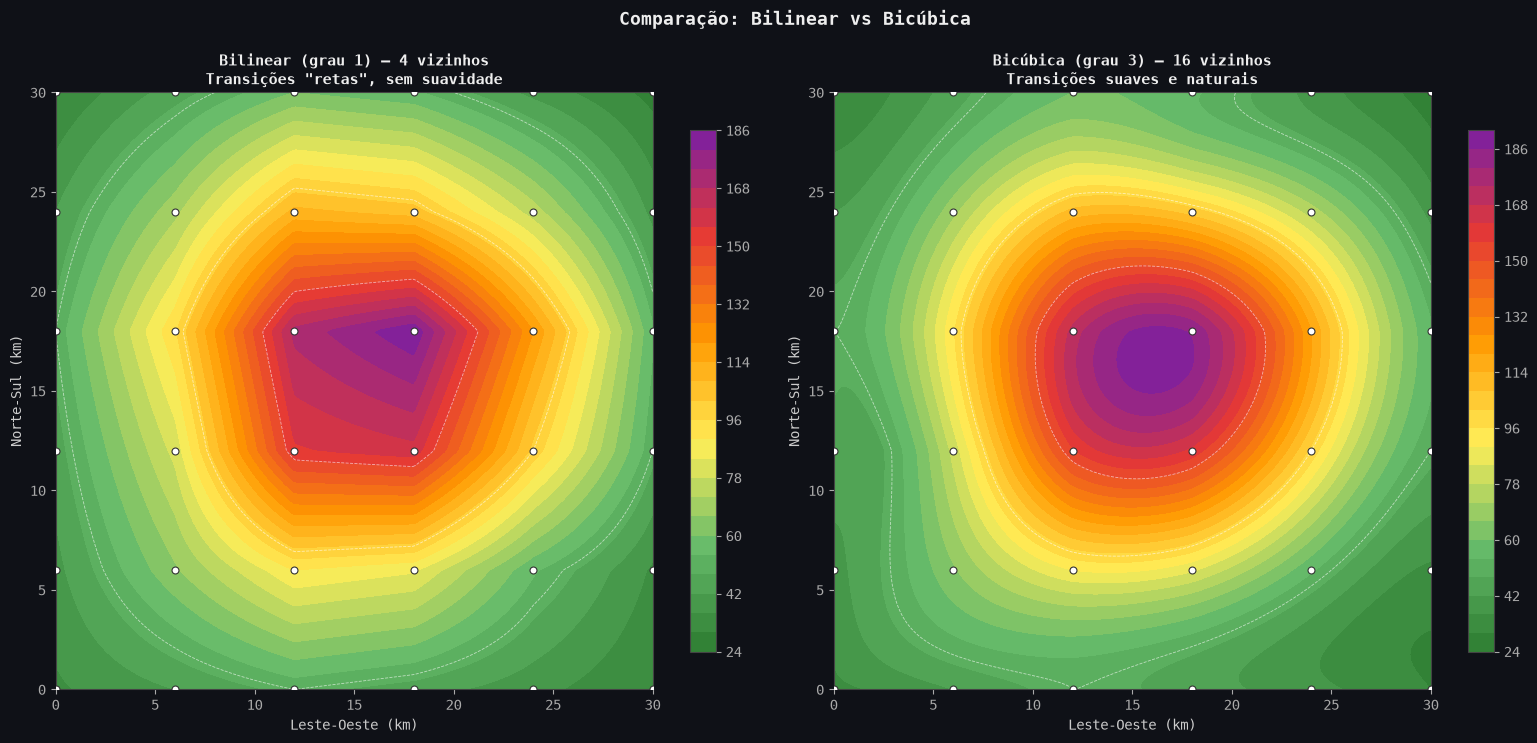

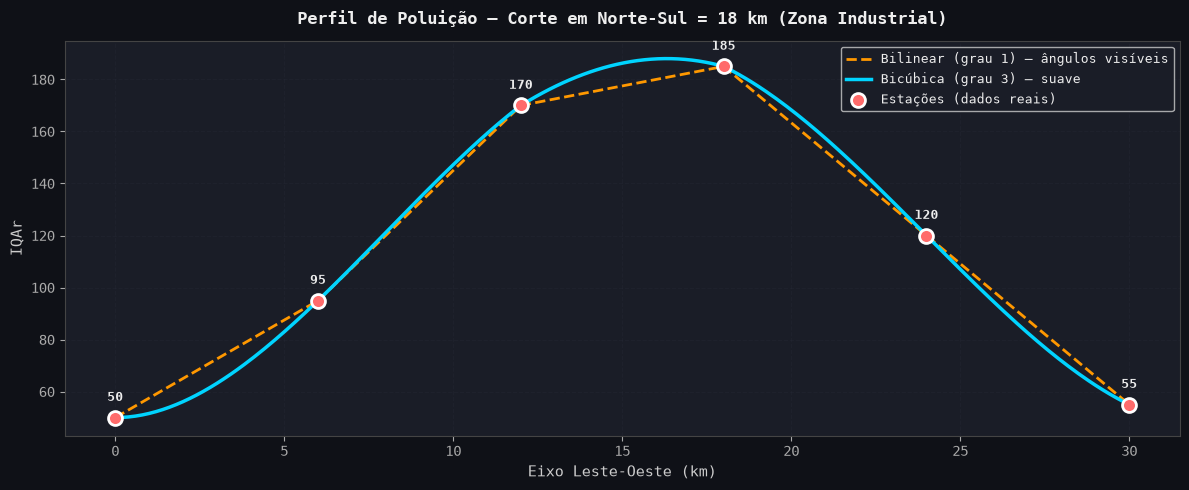

In [9]:

# FIGURA 3 — Comparação: Bilinear (grau 1) vs Bicúbica (grau 3)


def interpolacao_bilinear(x_grade, y_grade, Z_grade, x_alvo, y_alvo):
    """Interpolação bilinear (grau 1) — usa apenas 4 vizinhos (grade 2×2)."""
    ix = np.clip(np.searchsorted(x_grade, x_alvo) - 1, 0, len(x_grade) - 2)
    iy = np.clip(np.searchsorted(y_grade, y_alvo) - 1, 0, len(y_grade) - 2)
    
    x1, x2 = x_grade[ix], x_grade[ix + 1]
    y1, y2 = y_grade[iy], y_grade[iy + 1]
    
    t = (x_alvo - x1) / (x2 - x1) if x2 != x1 else 0
    u = (y_alvo - y1) / (y2 - y1) if y2 != y1 else 0
    
    z11 = Z_grade[iy, ix]
    z21 = Z_grade[iy, ix + 1]
    z12 = Z_grade[iy + 1, ix]
    z22 = Z_grade[iy + 1, ix + 1]
    
    return (1 - t)*(1 - u)*z11 + t*(1 - u)*z21 + (1 - t)*u*z12 + t*u*z22

# Gerar superfície bilinear
Z_bilinear = np.zeros_like(X_fino)
for i in range(resolucao):
    for j in range(resolucao):
        Z_bilinear[i, j] = interpolacao_bilinear(
            x_estacoes, y_estacoes, IQAr_grade, X_fino[0, j], Y_fino[i, 0]
        )

# --- Mapas lado a lado ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

im1 = ax1.contourf(X_fino, Y_fino, Z_bilinear, levels=30, cmap=cmap_ar)
ax1.contour(X_fino, Y_fino, Z_bilinear, levels=[50, 100, 150],
            colors='white', linewidths=0.6, linestyles='--', alpha=0.6)
ax1.scatter(Xg.ravel(), Yg.ravel(), c='white', s=25, edgecolors='#333', linewidths=0.8, zorder=5)
ax1.set_title('Bilinear (grau 1) — 4 vizinhos\nTransições "retas", sem suavidade',
              fontsize=11, fontweight='bold')
ax1.set_xlabel('Leste-Oeste (km)')
ax1.set_ylabel('Norte-Sul (km)')
ax1.set_aspect('equal')
fig.colorbar(im1, ax=ax1, shrink=0.82)

im2 = ax2.contourf(X_fino, Y_fino, Z_bicubica, levels=30, cmap=cmap_ar)
ax2.contour(X_fino, Y_fino, Z_bicubica, levels=[50, 100, 150],
            colors='white', linewidths=0.6, linestyles='--', alpha=0.6)
ax2.scatter(Xg.ravel(), Yg.ravel(), c='white', s=25, edgecolors='#333', linewidths=0.8, zorder=5)
ax2.set_title('Bicúbica (grau 3) — 16 vizinhos\nTransições suaves e naturais',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Leste-Oeste (km)')
ax2.set_ylabel('Norte-Sul (km)')
ax2.set_aspect('equal')
fig.colorbar(im2, ax=ax2, shrink=0.82)

fig.suptitle('Comparação: Bilinear vs Bicúbica',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════
# FIGURA 4 — Corte transversal comparando os dois métodos
# ═══════════════════════════════════════════════════════════════════════
y_corte = 18.0  # km (latitude da zona industrial)
x_perfil = np.linspace(0, 30, 300)

z_bilinear_perfil = np.array([
    interpolacao_bilinear(x_estacoes, y_estacoes, IQAr_grade, xp, y_corte)
    for xp in x_perfil
])
z_bicubica_perfil = np.array([
    interpolacao_bicubica(x_estacoes, y_estacoes, IQAr_grade, xp, y_corte)
    for xp in x_perfil
])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x_perfil, z_bilinear_perfil, color='#ff9800', lw=2, ls='--',
        label='Bilinear (grau 1) — ângulos visíveis')
ax.plot(x_perfil, z_bicubica_perfil, color='#00d4ff', lw=2.5,
        label='Bicúbica (grau 3) — suave')

# Estações nesta latitude
iy_corte = np.where(y_estacoes == y_corte)[0][0]
ax.scatter(x_estacoes, IQAr_grade[iy_corte, :], color='#ff6b6b', s=100,
           edgecolors='white', linewidths=2, zorder=5, label='Estações (dados reais)')

for k in range(len(x_estacoes)):
    ax.annotate(f'{IQAr_grade[iy_corte, k]:.0f}', (x_estacoes[k], IQAr_grade[iy_corte, k]),
                textcoords='offset points', xytext=(0, 12), fontsize=9, ha='center',
                color='#eee', fontweight='bold')

ax.set_xlabel('Eixo Leste-Oeste (km)', fontsize=11)
ax.set_ylabel('IQAr', fontsize=11)
ax.set_title(f'Perfil de Poluição — Corte em Norte-Sul = {y_corte:.0f} km (Zona Industrial)',
             fontsize=12, pad=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Análise dos Resultados

**O que o mapa nos mostra:**

- Com apenas **36 estações** dispostas em grade, a interpolação bicúbica reconstruiu uma superfície contínua e suave do IQAr sobre toda a cidade (~30×30 km).
- A zona industrial (Refinaria, Siderúrgica, Distrito Industrial) concentra os maiores índices de poluição (~155–185), enquanto a serra e o litoral mantêm ar mais limpo (~28–50).

**Os 4 passos em ação:**

| Passo                      | Descrição                    | O que acontece                                                |
| -------------------------- | ---------------------------- | ------------------------------------------------------------- |
| **1. Seleção**             | Grade 4×4 ao redor do alvo   | 16 estações são selecionadas para formar o raio de observação |
| **2. Varredura (eixo X)**  | 4 curvas cúbicas Leste-Oeste | Cada linha produz 1 valor intermediário no ponto alvo         |
| **3. Cruzamento (eixo Y)** | 1 curva cúbica Norte-Sul     | Os 4 valores intermediários são cruzados na outra direção     |
| **4. Colapso**             | Resultado final              | A união das duas direções entrega o IQAr estimado             |

**Por que a bicúbica é superior à bilinear?**

- A **bilinear** (grau 1) usa apenas **4 vizinhos** e produz transições angulares — o perfil tem "cotovelos" nos pontos de estação.
- A **bicúbica** (grau 3) usa **16 vizinhos** e produz transições **suaves e naturais** — o perfil é uma curva contínua sem quebras visíveis.
- No corte transversal da zona industrial, a diferença é evidente: a bicúbica captura o gradiente de poluição de forma muito mais realista.

**Por que a interpolação 1D falharia aqui?**

- A poluição em $(12, 18)$ depende tanto da proximidade a fábricas (eixo X) quanto da altitude/relevo (eixo Y).
- Usar apenas uma variável ignoraria completamente uma das dimensões espaciais, impossibilitando o mapeamento correto.
- O modelo precisa de **duas variáveis independentes** $(x, y)$ para representar a superfície $z = f(x, y)$.


## 7. Conclusão

- Use **Lagrange ou Newton** quando seus dados forem perfeitamente confiáveis e você precisar de precisão cirúrgica em valores intermediários.
- Use o **Método dos Mínimos Quadrados** para dados experimentais, extrair o sinal do ruído e calcular a tendência reduzindo o Desvio Total ($D$).

---

**Muito obrigada pela atenção!**
